# Problem Set 4: McCall Search with Time-Limited Unemployment Benefits

(Solutions)

David Evans  
2026-05-04

# Time-Limited Unemployment Benefits

In [1]:
β  = 0.95
S  = 100
w̄  = collect(LinRange(1., 10., S))
p  = ones(S) / S
c  = 3.0
c₀ = 0.0
D  = 12

12

## Problem 1: Setting Up the Model

**(a)** With the assumption that accepting a job exhausts UI
eligibility, the value of accepting offer $\bar{w}_s$ is
$\bar{w}_s + \beta V_{0,s}$ — the worker collects $\bar{w}_s$ this
period and continues from state $(0, s)$. The value of rejecting depends
on whether benefits are still available:

For $k \geq 1$: $$
V_{k,s} = \max\!\Big\{\, \bar{w}_s + \beta V_{0,s},\;\; c + \beta Q_{k-1} \,\Big\}.
$$

For $k = 0$: $$
V_{0,s} = \max\!\Big\{\, \bar{w}_s + \beta V_{0,s},\;\; c_0 + \beta Q_0 \,\Big\}.
$$

**(b)** When $k = 0$, both the accept and reject branches keep the
worker in the $k = 0$ regime forever. Rejecting yields $c_0$ this period
and a fresh draw from the same $V_{0,\cdot}$ next period, so
$V_{0,\cdot}$ is the fixed point of exactly the McCall Bellman from
lecture, with the unemployment benefit $c$ replaced by $c_0$.

## Problem 2: Solving the Model

**(a)** Bring in `iterateBellman` and `solveMcCall` from lecture
verbatim.

In [1]:
function iterateBellman(V, Q, β, p, w̄, c)
    V_accept = w̄ .+ β .* V
    V_reject = c + β * Q
    V_new = max.(V_accept, V_reject)
    Q_new = dot(p, V_new)
    C = V_accept .>= V_reject
    return (V = V_new, Q = Q_new, C = C)
end

iterateBellman (generic function with 1 method)

In [1]:
function solveMcCall(β, p, w̄, c)
    V = max.(w̄, c);  C = w̄ .>= c;  Q = dot(p, V)
    dist = 1.0
    while dist > 1e-10
        V_new, Q_new, C = iterateBellman(V, Q, β, p, w̄, c)
        dist = norm(V - V_new, Inf)
        V = V_new;  Q = Q_new
    end
    return (V = V, Q = Q, C = C)
end

solveMcCall (generic function with 1 method)

**(b)** The $k = 0$ problem is the standard McCall problem with benefit
$c_0$:

In [1]:
sol₀ = solveMcCall(β, p, w̄, c₀)
w_res₀ = w̄[findfirst(sol₀.C .== 1)]
println("k = 0 reservation wage: ", round(w_res₀, digits=2))

k = 0 reservation wage: 7.45


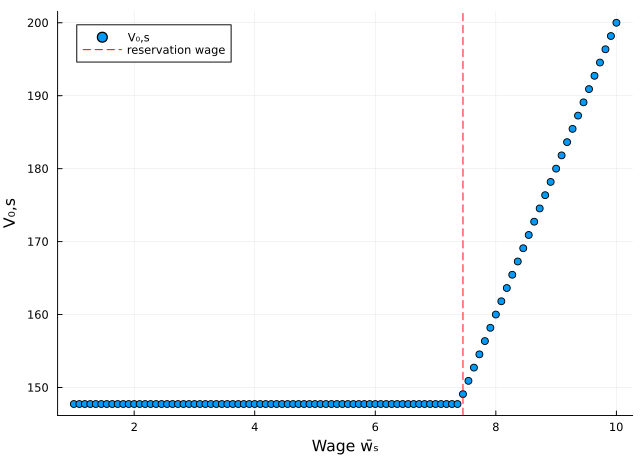

In [1]:
scatter(w̄, sol₀.V, label="V₀,s", legend=:topleft,
        xlabel="Wage w̄ₛ", ylabel="V₀,s")
vline!([w_res₀], label="reservation wage", linestyle=:dash, color=:red)

Even with $c_0 = 0$, the worker is still somewhat selective: the option
value of waiting for a higher draw exceeds the value of working forever
at a very low wage.

**(c)** `iterateBellman_withUI` implements the Bellman from Problem 1(a)
for $k \geq 1$. Because $V_{k,s}$ does not appear on the right-hand
side, this is a single update — no inner iteration:

In [1]:
function iterateBellman_withUI(V₀, Q_prev, β, p, w̄, c)
    V_accept = w̄ .+ β .* V₀          # accept: wage now + continue from (0, s)
    V_reject = c + β * Q_prev         # reject: benefit c + draw with k-1
    V_k = max.(V_accept, V_reject)
    Q_k = dot(p, V_k)
    C_k = V_accept .>= V_reject
    return (V = V_k, Q = Q_k, C = C_k)
end

iterateBellman_withUI (generic function with 1 method)

**(d)** `solveTimeLimited` runs the backward induction: row 1 is $k = 0$
(filled by `solveMcCall`), and rows $k+1 = 2, \ldots, D+1$ are filled by
`iterateBellman_withUI`.

In [1]:
function solveTimeLimited(β, p, w̄, c, c₀, D)
    S = length(w̄)
    sol₀ = solveMcCall(β, p, w̄, c₀)

    V = zeros(D+1, S)
    Q = zeros(D+1)
    C = zeros(Int, D+1, S)

    V[1, :] = sol₀.V                  # k = 0
    Q[1]    = sol₀.Q
    C[1, :] = sol₀.C

    V₀ = sol₀.V
    for k in 1:D
        ret = iterateBellman_withUI(V₀, Q[k], β, p, w̄, c)
        V[k+1, :] = ret.V
        Q[k+1]    = ret.Q
        C[k+1, :] = ret.C
    end
    return (V = V, Q = Q, C = C)
end

solveTimeLimited (generic function with 1 method)

**(e)** Solve and plot $V_{k,s}$ for several $k$:


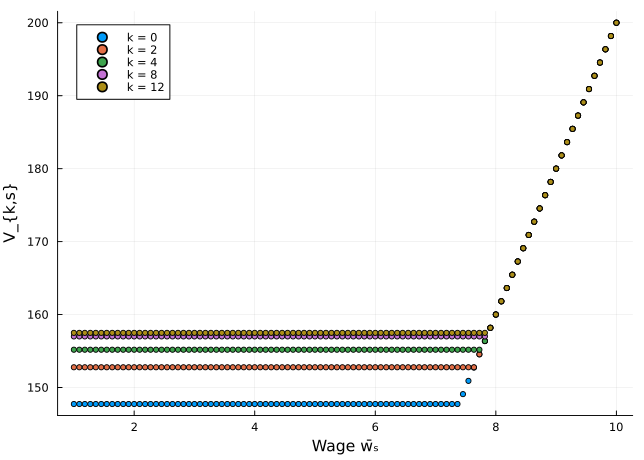

In [1]:
sol = solveTimeLimited(β, p, w̄, c, c₀, D)

plot(legend=:topleft, xlabel="Wage w̄ₛ", ylabel="V_{k,s}")
for k in [0, 2, 4, 8, 12]
    scatter!(w̄, sol.V[k+1, :], label="k = $k", markersize=3)
end
plot!()

$V_{k,s}$ shifts up with $k$: more periods of UI raise the value of
being unemployed. The shift is largest at low wages — high wages would
be accepted regardless of $k$, so their value (which equals
$\bar{w}_s/(1-\beta)$ once accepted) doesn’t depend on $k$.

## Problem 3: Reservation Wages Over the UI Spell

**(a)** Read off the reservation wage from the policy at each $k$.


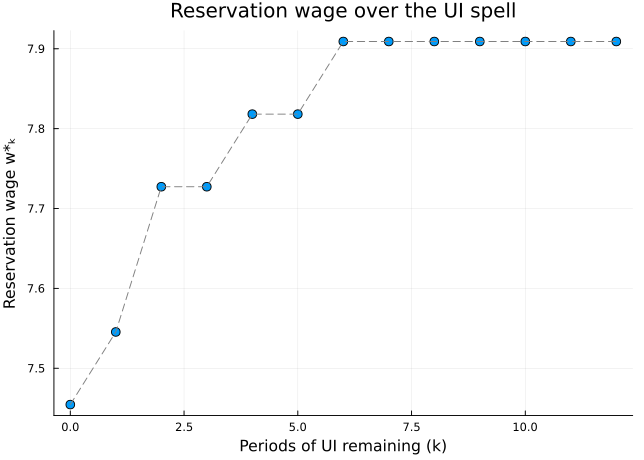

In [1]:
w_res = [w̄[findfirst(sol.C[k+1, :] .== 1)] for k in 0:D]

scatter(0:D, w_res, legend=false, markersize=5,
        xlabel="Periods of UI remaining (k)", ylabel="Reservation wage w*ₖ",
        title="Reservation wage over the UI spell")
plot!(0:D, w_res, linestyle=:dash, color=:gray)

The reservation wage is **increasing in $k$**: a worker with many weeks
of UI left can afford to wait for a better draw, while a worker close to
exhaustion accepts more readily because the cost of rejecting (forgoing
better-funded search next period) is rising.

**(b)** Hazard rate $h_k = p \cdot C_k$:


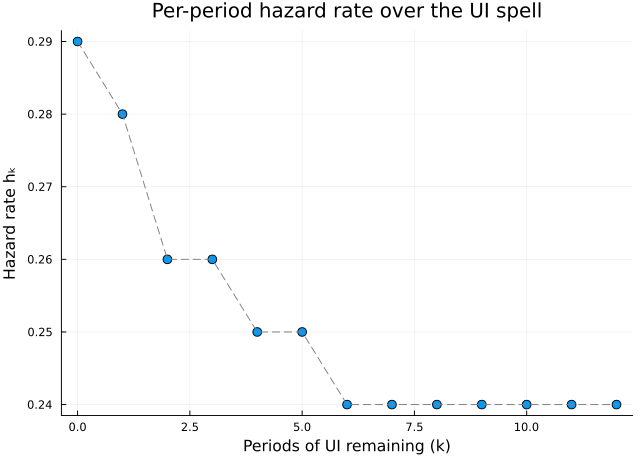

In [1]:
h = [dot(p, sol.C[k+1, :]) for k in 0:D]

scatter(0:D, h, legend=false, markersize=5,
        xlabel="Periods of UI remaining (k)", ylabel="Hazard rate hₖ",
        title="Per-period hazard rate over the UI spell")
plot!(0:D, h, linestyle=:dash, color=:gray)

The hazard rate **rises as benefits run down**: a less selective worker
accepts a wider range of offers. This qualitatively matches the
empirical finding that exit rates from unemployment spike near benefit
exhaustion. The model misses the *spike-and-drop* shape of the empirical
hazard (which our model produces as a smooth rise) — that pattern
requires additional ingredients such as anticipation effects under
non-stationary search effort.

## Problem 4: Comparative Statics

**(a)** Generosity of benefits $c$:


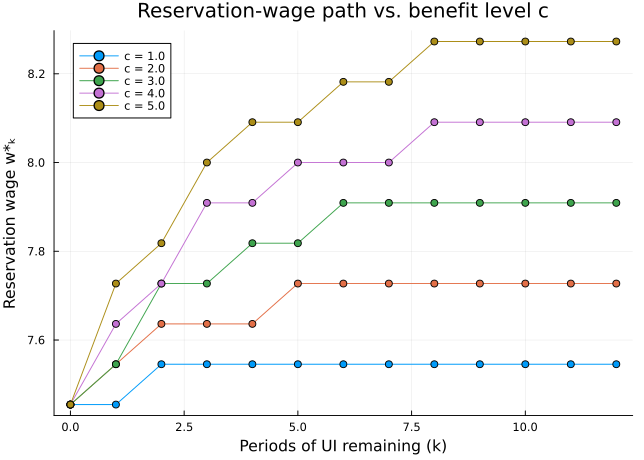

In [1]:
plot(legend=:topleft, xlabel="Periods of UI remaining (k)",
     ylabel="Reservation wage w*ₖ",
     title="Reservation-wage path vs. benefit level c")
for c_try in [1.0, 2.0, 3.0, 4.0, 5.0]
    sol_c = solveTimeLimited(β, p, w̄, c_try, 0.0, D)
    w_res_c = [w̄[findfirst(sol_c.C[k+1, :] .== 1)] for k in 0:D]
    plot!(0:D, w_res_c, marker=:circle, label="c = $c_try")
end
plot!()

Higher $c$ shifts the entire reservation-wage path up — more generous
benefits make the worker more selective at every $k$. The path also
becomes *steeper* as a function of $k$ for large $c$: the gap between
“having UI” and “no UI” is bigger when $c$ is bigger, so the reservation
wage falls more sharply as benefits run out.

**(b)** Length of benefits $D$. We plot in **reverse order** (longest
$D$ first, shortest on top) so the shorter curves overlay the longer
ones cleanly:


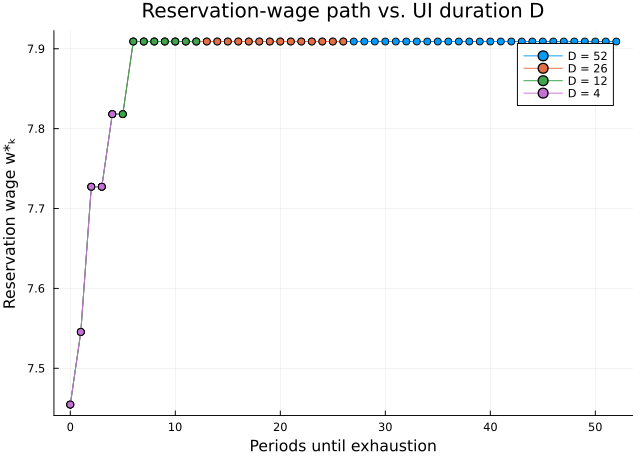

In [1]:
plot(legend=:topright, xlabel="Periods until exhaustion",
     ylabel="Reservation wage w*ₖ",
     title="Reservation-wage path vs. UI duration D")
for D_try in reverse([4, 12, 26, 52])
    sol_D = solveTimeLimited(β, p, w̄, 3.0, 0.0, D_try)
    w_res_D = [w̄[findfirst(sol_D.C[k+1, :] .== 1)] for k in 0:D_try]
    plot!(0:D_try, w_res_D, marker=:circle, label="D = $D_try")
end
plot!()

The four curves **lie exactly on top of one another** wherever they
overlap. The reservation wage at $k$ periods remaining depends only on
what happens *after* this moment, i.e. the path through
$k-1, k-2, \ldots, 0$, and that path is determined by backward induction
from the post-exhaustion problem, which doesn’t involve $D$ at all. So a
worker with 4 weeks of UI left faces *exactly* the same problem as one
with 4 weeks left out of an originally 52-week entitlement. It doesn’t
matter how much UI they started with, only how much remains. Plotting in
reverse order makes this overlap visible: the shorter curves sit
perfectly on the right end of the longer ones.

**(c)** Post-exhaustion safety net $c_0$ — the case $c_0 = c$ collapses
to the standard McCall model with permanent benefits.


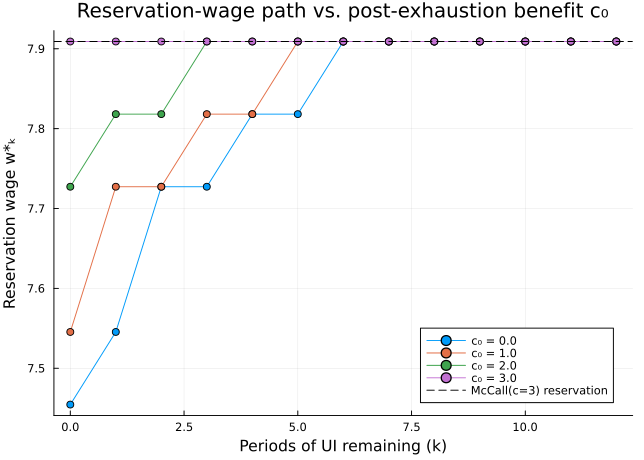

In [1]:
plot(legend=:bottomright, xlabel="Periods of UI remaining (k)",
     ylabel="Reservation wage w*ₖ",
     title="Reservation-wage path vs. post-exhaustion benefit c₀")
for c₀_try in [0.0, 1.0, 2.0, 3.0]
    sol_c0 = solveTimeLimited(β, p, w̄, 3.0, c₀_try, D)
    w_res_c0 = [w̄[findfirst(sol_c0.C[k+1, :] .== 1)] for k in 0:D]
    plot!(0:D, w_res_c0, marker=:circle, label="c₀ = $c₀_try")
end

# Sanity check: c₀ = c should equal standard McCall with c
sol_perm = solveMcCall(β, p, w̄, 3.0)
w_res_perm = w̄[findfirst(sol_perm.C .== 1)]
hline!([w_res_perm], linestyle=:dash, color=:black, label="McCall(c=3) reservation")

When $c_0 = 3 = c$, the reservation wage is **flat** at the standard
McCall reservation wage with $c = 3$ — confirming that the time-limited
code reduces to the lecture model when benefits are permanent. Smaller
$c_0$ pulls down the right end of the path (the post-exhaustion
reservation wage) without affecting the level when many periods of UI
remain.

## Problem 5: Simulating Unemployment Spells

**(a)** `simulateSpell` walks one worker through the spell. The worker
starts at $k = D$, draws an offer each period, consults `sol.C[k+1, s]`,
and either accepts (returning the spell statistics) or rejects and
decrements $k$.

In [1]:
function simulateSpell(sol, p, w̄, D; rng = Random.default_rng())
    k = D
    Tmax = 1000
    cat = Categorical(p)
    for t in 1:Tmax
        s = rand(rng, cat)
        if sol.C[k+1, s] == 1
            return (duration = t, wage = w̄[s], exhausted = (k == 0))
        end
        k = max(k - 1, 0)
    end
    return (duration = Tmax, wage = NaN, exhausted = true)
end

simulateSpell (generic function with 1 method)

**(b)** Simulate $N = 50{,}000$ spells with the baseline parameters:

In [1]:
function simulateMany(sol, p, w̄, D; N = 50_000, seed = 42)
    rng = MersenneTwister(seed)
    durations = zeros(Int, N)
    wages     = zeros(N)
    exhaust   = falses(N)
    for i in 1:N
        out = simulateSpell(sol, p, w̄, D; rng = rng)
        durations[i] = out.duration
        wages[i]     = out.wage
        exhaust[i]   = out.exhausted
    end
    return (mean_duration = mean(durations),
            frac_exhausted = mean(exhaust),
            mean_wage = mean(wages))
end

stats_base = simulateMany(sol, p, w̄, D)
println("Mean duration:           ", round(stats_base.mean_duration, digits=2))
println("Fraction exhausted:      ", round(stats_base.frac_exhausted, digits=3))
println("Mean accepted wage:      ", round(stats_base.mean_wage, digits=2))

Mean duration:           4.11
Fraction exhausted:      0.033
Mean accepted wage:      8.94

**(c)** Sweep $D \in \{4, 12, 26\}$:

In [1]:
println(rpad("D", 5), rpad("mean dur.", 12), rpad("frac exh.", 12), rpad("mean wage", 10))
println("-"^39)
for D_try in [4, 12, 26]
    sol_D = solveTimeLimited(β, p, w̄, c, c₀, D_try)
    s = simulateMany(sol_D, p, w̄, D_try)
    println(rpad(D_try, 5),
            rpad(round(s.mean_duration, digits=2), 12),
            rpad(round(s.frac_exhausted, digits=3), 12),
            rpad(round(s.mean_wage, digits=2), 10))
end

D    mean dur.   frac exh.   mean wage 
---------------------------------------
4    3.74        0.295       8.82      
12   4.11        0.033       8.94      
26   4.16        0.001       8.95      

As $D$ rises:

-   **Mean duration goes up** — longer benefits let the worker stay
    selective for more weeks before becoming impatient.
-   **Fraction exhausted falls** — with more UI weeks, the chance of
    getting a high enough draw before benefits run out is greater.
-   **Mean accepted wage goes up** — the worker holds out for better
    offers when subsidized for longer.

This is the classic UI trade-off: more generous (in level or duration)
benefits lengthen unemployment spells but improve match quality. The
optimal-UI literature (Baily 1978; Chetty 2008) studies exactly this
consumption-smoothing-vs-search-effort tension.